# 🔐 Advanced Fraud Detection in Financial Transactions
## Using Ensemble Models, Deep Neural Networks & Autoencoders

### Project Title
**Fraud Detection in Financial Transactions Using Ensemble Machine Learning Models**

**Dataset:** PaySim — Synthetic Financial Dataset for Fraud Detection  
**Source:** https://www.kaggle.com/datasets/ealaxi/paysim1  
**Size:** ~6.3 Million transactions | 10 features  
**Target:** `isFraud` (0 = Normal, 1 = Fraud)

---
**Models Used:**
1. Random Forest
2. XGBoost
3. LightGBM
4. Voting Ensemble (RF + XGBoost + LightGBM)
5. Deep Neural Network (DNN)
6. Autoencoder (Anomaly Detection)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1: Import Libraries

In [5]:
# ==================== Import Libraries ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb

# Imbalanced Learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import shap

# Model Saving
import joblib

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Load Dataset

**PaySim Dataset** simulates real mobile money transactions.  
It contains 6.3 million transactions over 30 days with clear fraud patterns.

| Column | Description |
|--------|-------------|
| `step` | Time unit (1 step = 1 hour, total 744 steps = 30 days) |
| `type` | Transaction type: CASH-IN, CASH-OUT, DEBIT, PAYMENT, TRANSFER |
| `amount` | Transaction amount in local currency |
| `nameOrig` | Sender account ID |
| `oldbalanceOrg` | Sender balance BEFORE transaction |
| `newbalanceOrig` | Sender balance AFTER transaction |
| `nameDest` | Receiver account ID |
| `oldbalanceDest` | Receiver balance BEFORE transaction |
| `newbalanceDest` | Receiver balance AFTER transaction |
| `isFraud` | **Target: 1 = Fraud, 0 = Normal** |
| `isFlaggedFraud` | System flagged (transfer > 200,000) |

In [6]:
# ==================== Load Dataset ====================
# Download from: https://www.kaggle.com/datasets/ealaxi/paysim1
# File name: PS_20174392719_1491204439457_log.csv
# Rename to paysim.csv for convenience

file_path = '/content/drive/MyDrive/paysim.csv'
df = pd.read_csv(file_path)  # update filename if needed

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn Names:", df.columns.tolist())

print("\nClass Distribution (isFraud):")
print(df['isFraud'].value_counts())

print("\nFraud Percentage: {:.4f}%".format(df['isFraud'].mean() * 100))

Dataset Shape: (6362620, 11)

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0



Column Names: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Class Distribution (isFraud):
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage: 0.1291%


## Step 3: Exploratory Data Analysis (EDA)

In [7]:
# Missing values & data types
print("Total Missing Values:", df.isnull().sum().sum())
print("\nData Types:")
print(df.dtypes)

Total Missing Values: 0

Data Types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


### Class Distribution

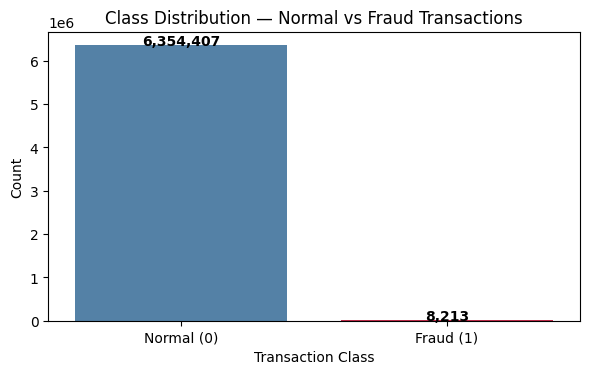

Observation: Dataset is highly imbalanced — we will use SMOTE to handle this.


In [8]:
# Class Distribution
plt.figure(figsize=(6,4))
fraud_counts = df['isFraud'].value_counts()
sns.barplot(x=['Normal (0)', 'Fraud (1)'], y=fraud_counts.values, palette=['steelblue', 'crimson'])
plt.title('Class Distribution — Normal vs Fraud Transactions')
plt.xlabel('Transaction Class')
plt.ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    plt.text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Observation: Dataset is highly imbalanced — we will use SMOTE to handle this.")

### Transaction Type Distribution

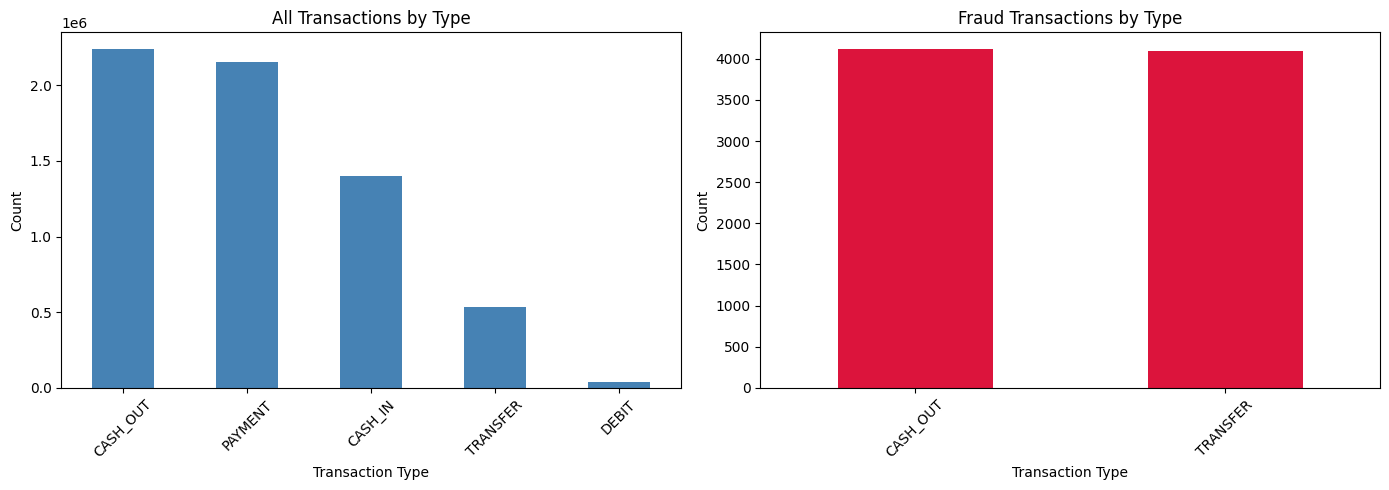

Observation: Fraud ONLY occurs in CASH-OUT and TRANSFER transactions!


In [9]:
# Transaction Type Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All transactions by type
df['type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('All Transactions by Type')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Fraud transactions by type
df[df['isFraud']==1]['type'].value_counts().plot(kind='bar', ax=axes[1], color='crimson')
axes[1].set_title('Fraud Transactions by Type')
axes[1].set_xlabel('Transaction Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('transaction_types.png', dpi=150)
plt.show()
print("Observation: Fraud ONLY occurs in CASH-OUT and TRANSFER transactions!")

### Transaction Amount Distribution

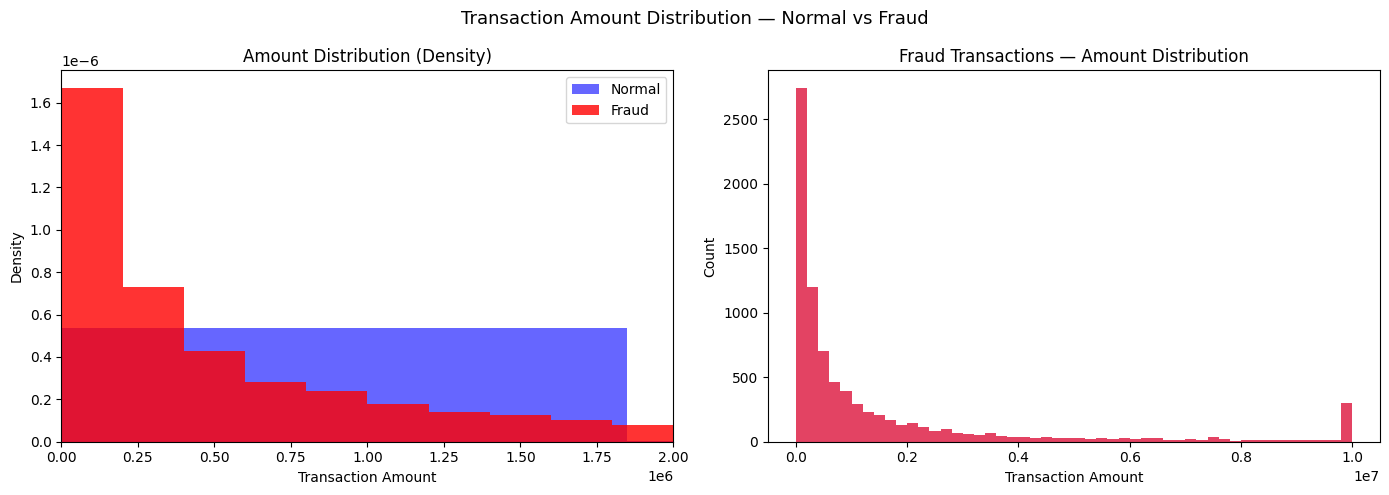

In [ ]:
# Amount Distribution — Better Version
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Use log scale so both classes remain visible
axes[0].hist(df[df['isFraud']==0]['amount'], bins=50,
             color='blue', label='Normal', alpha=0.6, density=True)
axes[0].hist(df[df['isFraud']==1]['amount'], bins=50,
             color='red', label='Fraud', alpha=0.8, density=True)
axes[0].set_title('Amount Distribution (Density)')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Density')
axes[0].set_xlim(0, 2000000)
axes[0].legend()

# Right: Sirf Fraud transactions distribution
axes[1].hist(df[df['isFraud']==1]['amount'], bins=50,
             color='crimson', alpha=0.8)
axes[1].set_title('Fraud Transactions — Amount Distribution')
axes[1].set_xlabel('Transaction Amount')
axes[1].set_ylabel('Count')

plt.suptitle('Transaction Amount Distribution — Normal vs Fraud', fontsize=13)
plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150)
plt.show()

### Fraud Rate by Transaction Type

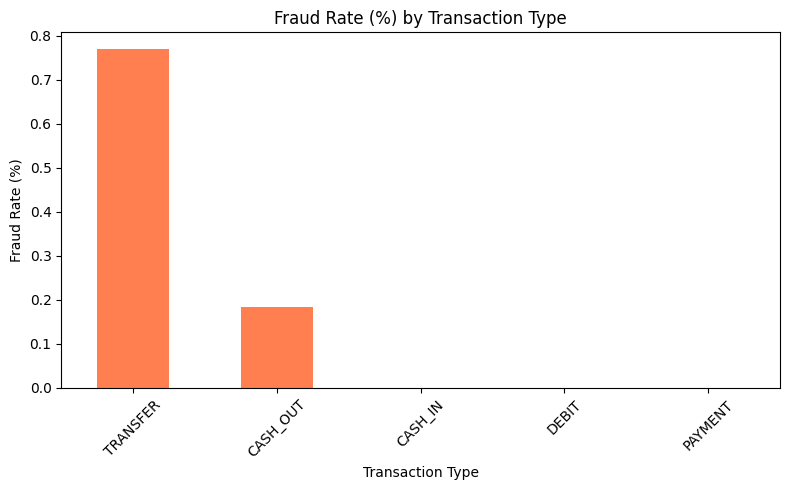

In [12]:
# Fraud Rate by Type
plt.figure(figsize=(8,5))
fraud_rate = df.groupby('type')['isFraud'].mean() * 100
fraud_rate.sort_values(ascending=False).plot(kind='bar', color='coral')
plt.title('Fraud Rate (%) by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fraud_rate_by_type.png', dpi=150)
plt.show()

### Balance Before vs After (Fraud Pattern)

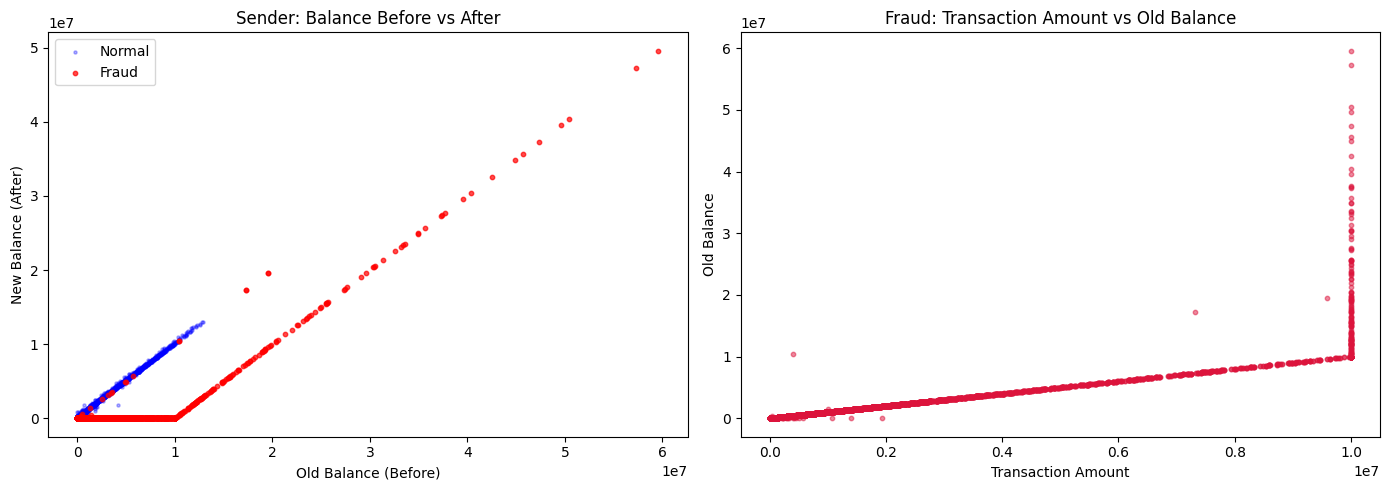

Key Observation: In fraud cases, sender balance drops to 0 after transaction!


In [13]:
# Key Fraud Pattern: Balance goes to ZERO after fraud transaction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sender balance before vs after
axes[0].scatter(df[df['isFraud']==0]['oldbalanceOrg'][:5000],
                df[df['isFraud']==0]['newbalanceOrig'][:5000],
                alpha=0.3, color='blue', s=5, label='Normal')
axes[0].scatter(df[df['isFraud']==1]['oldbalanceOrg'],
                df[df['isFraud']==1]['newbalanceOrig'],
                alpha=0.7, color='red', s=10, label='Fraud')
axes[0].set_title('Sender: Balance Before vs After')
axes[0].set_xlabel('Old Balance (Before)')
axes[0].set_ylabel('New Balance (After)')
axes[0].legend()

# Fraud transactions: amount vs old balance
fraud_data = df[df['isFraud']==1]
axes[1].scatter(fraud_data['amount'], fraud_data['oldbalanceOrg'],
                alpha=0.5, color='crimson', s=10)
axes[1].set_title('Fraud: Transaction Amount vs Old Balance')
axes[1].set_xlabel('Transaction Amount')
axes[1].set_ylabel('Old Balance')

plt.tight_layout()
plt.savefig('balance_analysis.png', dpi=150)
plt.show()
print("Key Observation: In fraud cases, sender balance drops to 0 after transaction!")

### Correlation Heatmap

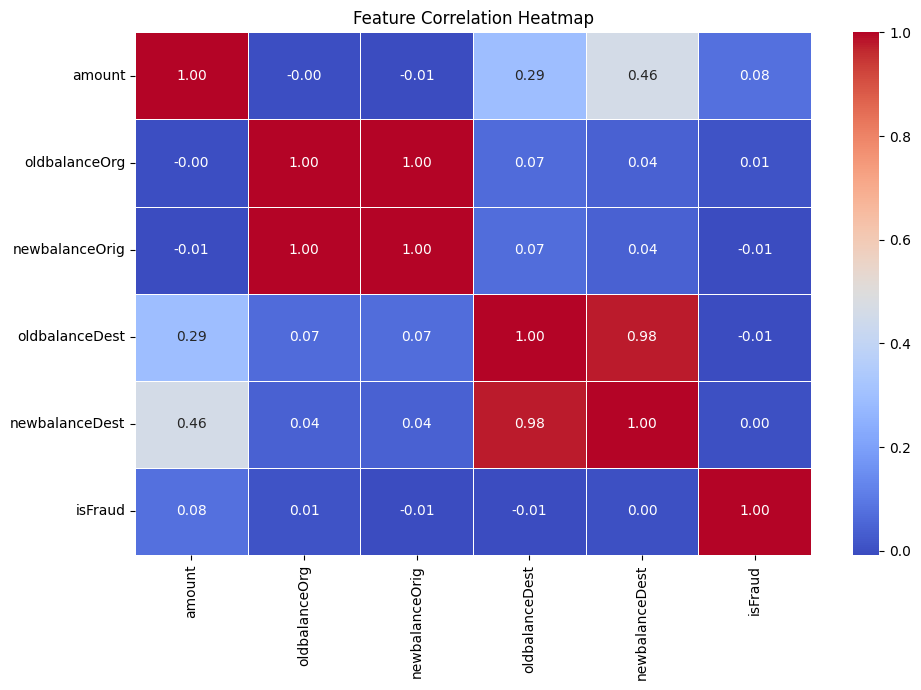

In [14]:
# Correlation Heatmap
plt.figure(figsize=(10, 7))
num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest', 'isFraud']
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, linewidths=0.5, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

## Step 4: Data Preprocessing

**Steps:**
1. Drop identifier columns (nameOrig, nameDest, isFlaggedFraud)
2. Encode `type` column (categorical → numerical)
3. Engineer new features (balance difference)
4. Train-test split
5. Feature scaling

In [15]:
# ==================== Feature Engineering ====================
# Add meaningful features that help detect fraud

# 1. Balance difference for sender (should be = amount for fraud)
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']

# 2. Balance difference for receiver
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# 3. Flag if sender balance went to zero
df['origBalanceZero'] = (df['newbalanceOrig'] == 0).astype(int)

print("✅ Feature engineering completed!")
print("New features: errorBalanceOrig, errorBalanceDest, origBalanceZero")

✅ Feature engineering completed!
New features: errorBalanceOrig, errorBalanceDest, origBalanceZero


In [16]:
# ==================== Drop Unnecessary Columns ====================
cols_to_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud']
df_clean = df.drop(columns=cols_to_drop)

# ==================== Encode Transaction Type ====================
le = LabelEncoder()
df_clean['type'] = le.fit_transform(df_clean['type'])
print("Transaction type encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

print("\nFinal shape:", df_clean.shape)
print("\nClass distribution:")
print(df_clean['isFraud'].value_counts())

Transaction type encoding:
  CASH_IN → 0
  CASH_OUT → 1
  DEBIT → 2
  PAYMENT → 3
  TRANSFER → 4

Final shape: (6362620, 11)

Class distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [17]:
# ==================== Separate Features & Target ====================
X = df_clean.drop(columns=['isFraud'])
y = df_clean['isFraud']

print("Features:", X.columns.tolist())
print("Target: isFraud")

# ==================== Train-Test Split ====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {X_train.shape[0]:,}")
print(f"Testing samples:  {X_test.shape[0]:,}")

# ==================== Feature Scaling ====================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, 'scaler.pkl')
# Save label encoder
joblib.dump(le, 'label_encoder.pkl')

print("\n✅ Scaler saved as 'scaler.pkl'")
print("✅ Label Encoder saved as 'label_encoder.pkl'")
print("✅ Data preprocessing completed!")

Features: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'origBalanceZero']
Target: isFraud

Training samples: 5,090,096
Testing samples:  1,272,524

✅ Scaler saved as 'scaler.pkl'
✅ Label Encoder saved as 'label_encoder.pkl'
✅ Data preprocessing completed!


## Step 5: Handling Class Imbalance using SMOTE + Undersampling

PaySim has only **0.13% fraud cases** — extreme imbalance!  
We use a combined strategy:
- **SMOTE** → oversample fraud cases
- **RandomUnderSampler** → reduce normal cases
- This avoids memory issues on large dataset

In [18]:
# ==================== SMOTE + Undersampling Pipeline ====================
print("Before resampling:")
print(pd.Series(y_train).value_counts())

# Combined pipeline: SMOTE then undersample
over  = SMOTE(sampling_strategy=0.1, random_state=42)   # fraud → 10% of majority
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # then 1:2 ratio

pipeline = Pipeline([('over', over), ('under', under)])
X_train_resampled, y_train_resampled = pipeline.fit_resample(X_train_scaled, y_train)

print("\nAfter resampling:")
print(pd.Series(y_train_resampled).value_counts())
print("\n✅ Resampling completed successfully!")

Before resampling:
isFraud
0    5083526
1       6570
Name: count, dtype: int64

After resampling:
isFraud
0    1016704
1     508352
Name: count, dtype: int64

✅ Resampling completed successfully!


## Step 6: Training Machine Learning Models

In [19]:
# Dictionary to store AUC-ROC results
results = {}

# ==================== 1. Random Forest ====================
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test_scaled)

print("\n📊 Random Forest Results:")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraud']))
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:,1])
print("AUC-ROC:", round(rf_auc, 4))
results['Random Forest'] = rf_auc

Training Random Forest...

📊 Random Forest Results:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1270881
       Fraud       0.97      1.00      0.98      1643

    accuracy                           1.00   1272524
   macro avg       0.98      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524

AUC-ROC: 0.9997


In [20]:
# ==================== 2. XGBoost ====================
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)
xgb_model.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("\n📊 XGBoost Results:")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Fraud']))
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test_scaled)[:,1])
print("AUC-ROC:", round(xgb_auc, 4))
results['XGBoost'] = xgb_auc

Training XGBoost...

📊 XGBoost Results:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1270881
       Fraud       0.80      1.00      0.89      1643

    accuracy                           1.00   1272524
   macro avg       0.90      1.00      0.95   1272524
weighted avg       1.00      1.00      1.00   1272524

AUC-ROC: 0.9999


In [21]:
# ==================== 3. LightGBM ====================
print("Training LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
lgb_model.fit(X_train_resampled, y_train_resampled)
y_pred_lgb = lgb_model.predict(X_test_scaled)

print("\n📊 LightGBM Results:")
print(classification_report(y_test, y_pred_lgb, target_names=['Normal', 'Fraud']))
lgb_auc = roc_auc_score(y_test, lgb_model.predict_proba(X_test_scaled)[:,1])
print("AUC-ROC:", round(lgb_auc, 4))
results['LightGBM'] = lgb_auc

Training LightGBM...

📊 LightGBM Results:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1270881
       Fraud       0.91      1.00      0.95      1643

    accuracy                           1.00   1272524
   macro avg       0.96      1.00      0.98   1272524
weighted avg       1.00      1.00      1.00   1272524

AUC-ROC: 1.0


In [22]:
# ==================== 4. Voting Ensemble ====================
print("Training Voting Ensemble (RF + XGBoost + LightGBM)...")
ensemble = VotingClassifier(
    estimators=[
        ('rf',  rf),
        ('xgb', xgb_model),
        ('lgb', lgb_model)
    ],
    voting='soft'
)
ensemble.fit(X_train_resampled, y_train_resampled)
y_pred_ens      = ensemble.predict(X_test_scaled)
y_pred_ens_prob = ensemble.predict_proba(X_test_scaled)[:,1]

print("\n📊 Voting Ensemble Results:")
print(classification_report(y_test, y_pred_ens, target_names=['Normal', 'Fraud']))
ens_auc = roc_auc_score(y_test, y_pred_ens_prob)
print("AUC-ROC:", round(ens_auc, 4))
results['Voting Ensemble'] = ens_auc

Training Voting Ensemble (RF + XGBoost + LightGBM)...

📊 Voting Ensemble Results:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1270881
       Fraud       0.96      1.00      0.98      1643

    accuracy                           1.00   1272524
   macro avg       0.98      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524

AUC-ROC: 1.0


## Step 7: Deep Neural Network (DNN)

In [23]:
# ==================== 5. Deep Neural Network ====================
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_resampled.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

early_stop = EarlyStopping(monitor='val_auc', patience=5,
                            restore_best_weights=True, mode='max')
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-6)

print("✅ DNN Model Built:")
model.summary()

✅ DNN Model Built:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,873 (187.00 KB)

 Trainable params: 46,977 (183.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [24]:
# Train DNN
history = model.fit(
    X_train_resampled, y_train_resampled,
    epochs=50,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate
y_pred_dnn_prob = model.predict(X_test_scaled)
y_pred_dnn      = (y_pred_dnn_prob > 0.5).astype(int)

print("\n📊 Deep Neural Network Results:")
print(classification_report(y_test, y_pred_dnn, target_names=['Normal', 'Fraud']))
dnn_auc = roc_auc_score(y_test, y_pred_dnn_prob)
print("AUC-ROC:", round(dnn_auc, 4))
results['Deep Neural Network'] = dnn_auc

Epoch 1/50
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - accuracy: 0.9851 - auc: 0.9971 - loss: 0.0405 - precision: 0.9513 - recall: 0.9597 - val_accuracy: 0.9920 - val_auc: 0.0000e+00 - val_loss: 0.0490 - val_precision: 1.0000 - val_recall: 0.9920 - learning_rate: 0.0010
Epoch 2/50
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9939 - auc: 0.9985 - loss: 0.0190 - precision: 0.9780 - recall: 0.9859 - val_accuracy: 0.9926 - val_auc: 0.0000e+00 - val_loss: 0.0396 - val_precision: 1.0000 - val_recall: 0.9926 - learning_rate: 0.0010
Epoch 3/50
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9948 - auc: 0.9987 - loss: 0.0167 - precision: 0.9814 - recall: 0.9874 - val_accuracy: 0.9929 - val_auc: 0.0000e+00 - val_loss: 0.0384 - val_precision: 1.0000 - val_recall: 0.9929 - learning_rate: 0.0010
Epoch 4/50
2383/2383 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9952 - auc: 0.9988 - loss: 0.0158 - precision: 0.9826 - recall: 0.9885 - val_accuracy: 0.9895 - val_auc: 0.0000e+

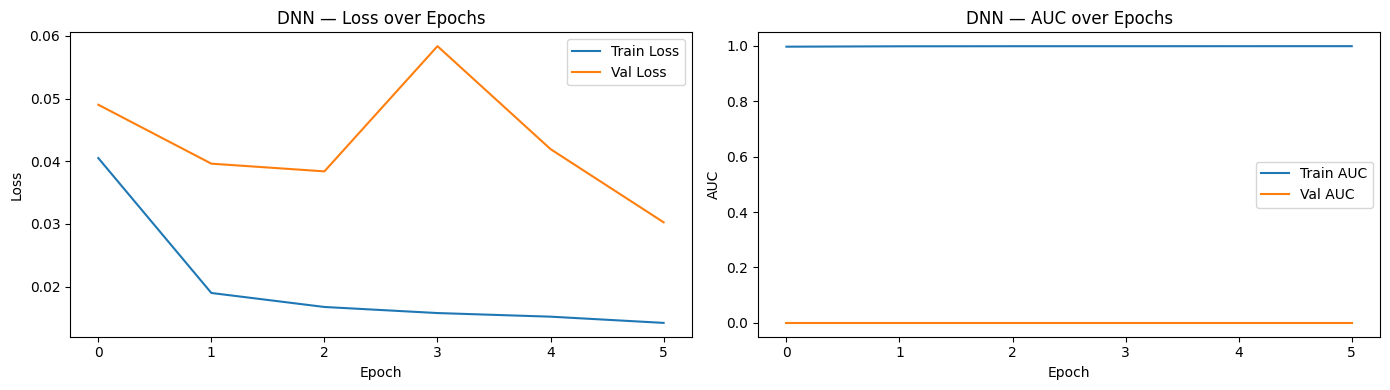

In [25]:
# Plot DNN Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('DNN — Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('DNN — AUC over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.tight_layout()
plt.savefig('dnn_training_history.png', dpi=150)
plt.show()

## Step 8: Autoencoder for Anomaly Detection

Autoencoder learns what **normal transactions look like**.  
When it sees a fraud transaction, reconstruction error is HIGH → flagged as fraud!

In [26]:
# ==================== 6. Autoencoder ====================
input_dim = X_train_resampled.shape[1]

autoencoder = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(input_dim, activation='sigmoid')
])

autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
print("✅ Autoencoder Built:")
autoencoder.summary()

✅ Autoencoder Built:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,618 (25.85 KB)

 Trainable params: 6,618 (25.85 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==================== Autoencoder Fix ====================

# Train ONLY on ORIGINAL normal transactions (not SMOTE wala)
# After applying SMOTE, the pattern of normal transactions becomes distorted
X_train_normal = X_train_scaled[y_train == 0]  
print(f"Training on {len(X_train_normal):,} real normal transactions...")

history_ae = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=50,           # 30 se 50 karo
    batch_size=256,      # 512 se 256 karo
    validation_split=0.1,
    verbose=1
)

# Reconstruction Error
reconstructions = autoencoder.predict(X_test_scaled)
mse = np.mean(np.power(X_test_scaled - reconstructions, 2), axis=1)

# Try a better threshold using the 90th percentile
threshold = np.percentile(mse, 90)
print(f"Threshold: {threshold:.4f}")



Training on 5,083,526 real normal transactions...
Epoch 1/50
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 72s 4ms/step - loss: 0.6818 - val_loss: 0.6914
Epoch 2/50
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 0.6796 - val_loss: 0.6913
Epoch 3/50
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 52s 3ms/step - loss: 0.6795 - val_loss: 0.6912
Epoch 4/50
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 53s 3ms/step - loss: 0.6795 - val_loss: 0.6917
Epoch 5/50
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 80s 3ms/step - loss: 0.6794 - val_loss: 0.6912
Epoch 6/50
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 52s 3ms/step - loss: 0.6794 - val_loss: 0.6914
Epoch 7/50
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 0.6794 - val_loss: 0.6912
Epoch 8/50
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 0.6794 - val_loss: 0.6913
Epoch 9/50
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 0.6794 - val_loss: 0.6912
Epoch 10/50
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 0.6794 - val_loss: 0.6912
Epoch 11/50
17872/17872 ━━━━━━━━━━━━━━━

Autoencoder Results:
              precision    recall  f1-score   support

      Normal       1.00      0.90      0.95   1270881
       Fraud       0.00      0.31      0.01      1643

    accuracy                           0.90   1272524
   macro avg       0.50      0.61      0.48   1272524
weighted avg       1.00      0.90      0.95   1272524

AUC-ROC: 0.6512


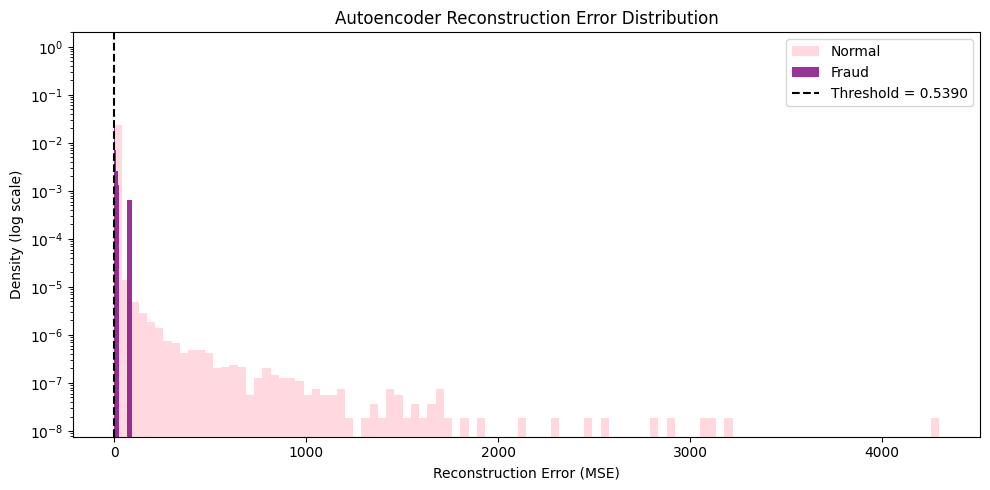

In [ ]:
# Autoencoder Predictions
y_pred_ae = (mse > threshold).astype(int)

print("Autoencoder Results:")
print(classification_report(y_test, y_pred_ae,
      target_names=['Normal', 'Fraud']))
ae_auc = roc_auc_score(y_test, mse)
print("AUC-ROC:", round(ae_auc, 4))
results['Autoencoder'] = ae_auc

# Fixed Plot — use log scale 
plt.figure(figsize=(10,5))
plt.hist(mse[y_test == 0], bins=100, alpha=0.6,
         color='pink', label='Normal', density=True)
plt.hist(mse[y_test == 1], bins=100, alpha=0.8,
         color='purple', label='Fraud', density=True)
plt.axvline(threshold, color='black', linestyle='--',
            label=f'Threshold = {threshold:.4f}')
plt.yscale('log')        # <-- Log scale helps make fraudulent transactions visible
plt.title('Autoencoder Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density (log scale)')
plt.legend()
plt.tight_layout()
plt.savefig('autoencoder_error.png', dpi=150)
plt.show()

## Step 9: Final Model Comparison

🏆 Final Model Comparison:


,Model,AUC-ROC
0,Voting Ensemble,0.999961
1,LightGBM,0.999950
2,XGBoost,0.999940
3,Random Forest,0.999686
4,Deep Neural Network,0.999600
5,Autoencoder,0.651199


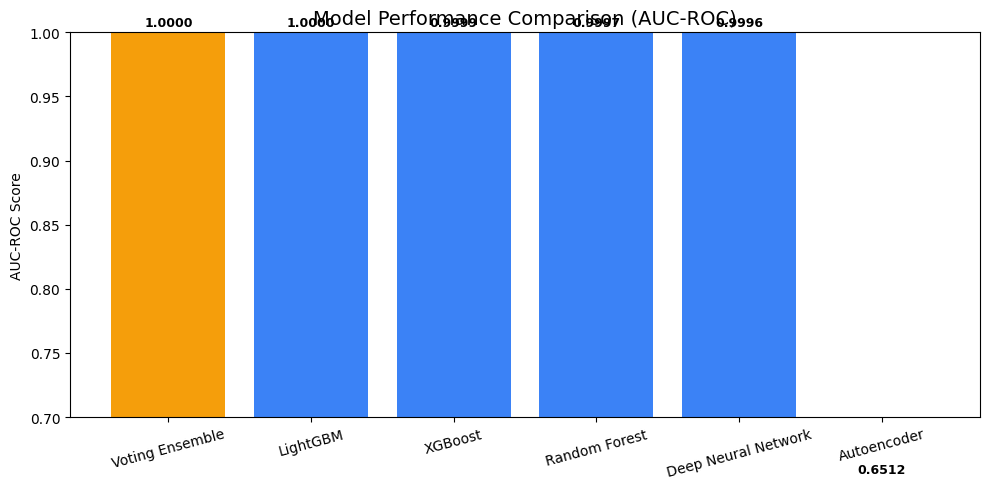


🥇 Best Model: Voting Ensemble (AUC-ROC: 1.0000)


In [30]:
# ==================== Final Model Comparison ====================
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'AUC-ROC': list(results.values())
})
comparison = comparison.sort_values(by='AUC-ROC', ascending=False).reset_index(drop=True)

print("🏆 Final Model Comparison:")
display(comparison)

# Bar Chart
plt.figure(figsize=(10, 5))
colors = ['#f59e0b' if m == comparison.iloc[0]['Model'] else '#3b82f6'
          for m in comparison['Model']]
bars = plt.bar(comparison['Model'], comparison['AUC-ROC'], color=colors)
plt.title('Model Performance Comparison (AUC-ROC)', fontsize=14)
plt.ylabel('AUC-ROC Score')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=15)

# Add value labels on bars
for bar, val in zip(bars, comparison['AUC-ROC']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print(f"\n🥇 Best Model: {comparison.iloc[0]['Model']} (AUC-ROC: {comparison.iloc[0]['AUC-ROC']:.4f})")

## Step 10: SHAP Explainability

SHAP tells us **which features matter most** for fraud detection — this is key for explaining to teachers and at Tech Expo!

Generating SHAP values for LightGBM...


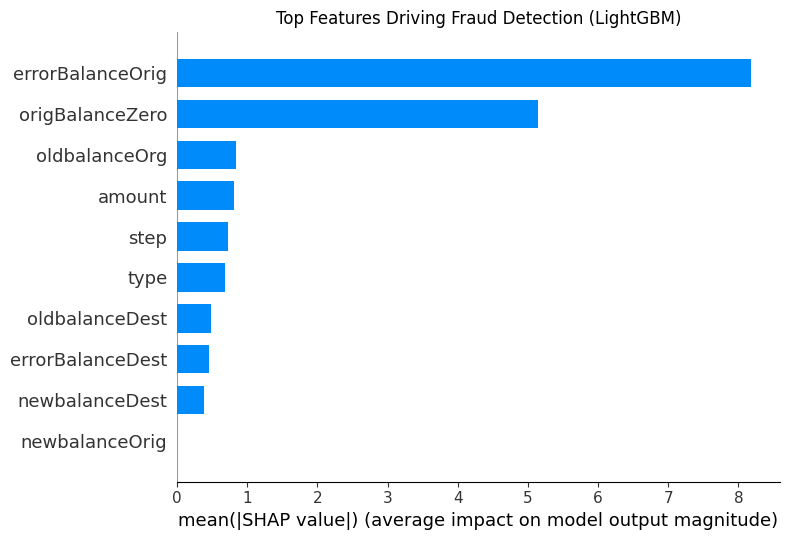

✅ SHAP bar plot saved!


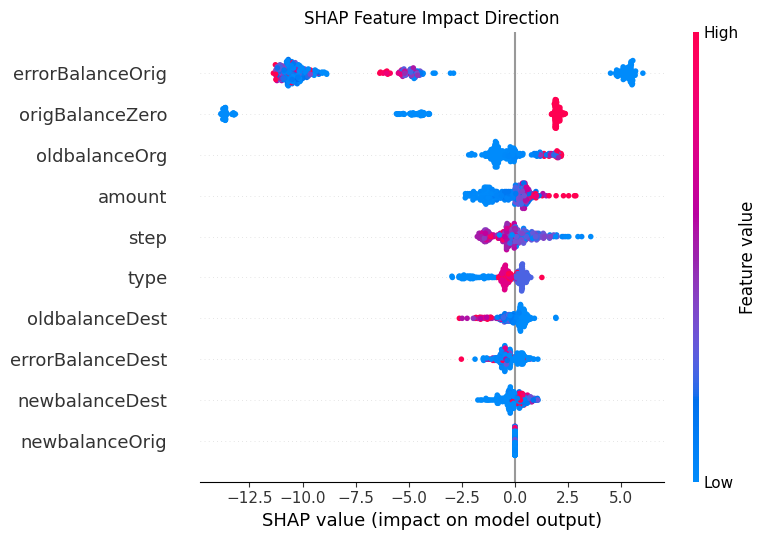

✅ SHAP beeswarm plot saved!


In [31]:
# ==================== SHAP Explainability (LightGBM) ====================
print("Generating SHAP values for LightGBM...")

explainer = shap.TreeExplainer(lgb_model)
X_sample  = pd.DataFrame(X_test_scaled[:300], columns=X.columns)
shap_values = explainer.shap_values(X_sample)

# Handle different SHAP versions
if isinstance(shap_values, list):
    sv = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    sv = np.array(shap_values)[:, :, 1]
else:
    sv = shap_values

# Bar plot — Top features
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_sample, plot_type="bar", show=False)
plt.title("Top Features Driving Fraud Detection (LightGBM)")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP bar plot saved!")

# Beeswarm plot — Direction of impact
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_sample, plot_type="dot", show=False)
plt.title("SHAP Feature Impact Direction")
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP beeswarm plot saved!")

In [32]:
# ==================== Save Best Model ====================
best_model_name = comparison.iloc[0]['Model']
print(f"🏆 Best Model: {best_model_name}")

if best_model_name == 'LightGBM':
    joblib.dump(lgb_model, 'best_fraud_model.pkl')
elif best_model_name == 'Voting Ensemble':
    joblib.dump(ensemble, 'best_fraud_model.pkl')
elif best_model_name == 'XGBoost':
    joblib.dump(xgb_model, 'best_fraud_model.pkl')
elif best_model_name == 'Random Forest':
    joblib.dump(rf, 'best_fraud_model.pkl')
else:
    model.save('best_fraud_model_dnn.h5')

# Always save LightGBM (used for SHAP)
joblib.dump(lgb_model, 'lgb_model.pkl')

print("✅ Best model saved as 'best_fraud_model.pkl'")
print("✅ LightGBM saved as 'lgb_model.pkl'")
print("✅ Scaler saved as 'scaler.pkl'")
print("✅ Label Encoder saved as 'label_encoder.pkl'")
print("\n🎉 Project Complete! All models trained and saved successfully!")

🏆 Best Model: Voting Ensemble
✅ Best model saved as 'best_fraud_model.pkl'
✅ LightGBM saved as 'lgb_model.pkl'
✅ Scaler saved as 'scaler.pkl'
✅ Label Encoder saved as 'label_encoder.pkl'

🎉 Project Complete! All models trained and saved successfully!


---
## 📋 Project Summary

### Dataset
- **PaySim** — Synthetic Mobile Money Transactions
- 6.3 Million transactions | 30 days simulation
- Fraud only in **CASH-OUT** and **TRANSFER** types

### Models Trained
| Model | Type |
|-------|------|
| Random Forest | Traditional ML |
| XGBoost | Gradient Boosting |
| LightGBM | Gradient Boosting |
| Voting Ensemble | Ensemble (RF+XGB+LGB) |
| Deep Neural Network | Deep Learning |
| Autoencoder | Anomaly Detection |

### Key Techniques
- **SMOTE + Undersampling** — Class imbalance handling
- **Feature Engineering** — Balance error features
- **SHAP** — Model explainability
- **Early Stopping** — Prevent DNN overfitting

### Files Saved
- `best_fraud_model.pkl` — Best performing model
- `lgb_model.pkl` — LightGBM (for SHAP)
- `scaler.pkl` — StandardScaler
- `label_encoder.pkl` — Type encoder